In [1]:
%run import_libs

In [2]:
import multimatch_gaze as m

In [3]:
root = 'Z:/yueying/gazeObject_YueyingDong/results/'

# load multimatch

In [4]:
loadRaw = False
mergeTags = False
loadScanpath = True
trlType = ['precue','retrocue']
comparison = 'stim2delay'


In [5]:
"""load trial ordering"""
precuePath1 = glob.glob(root + "variables/scanMatchTrlOrdering/311to352/*.csv")
retrocuePath1 = glob.glob(root + "variables/scanMatchTrlOrdering/360to400/*.csv")

#load trial info
if len(trlType) != 0:
    thisPath = precuePath1 + retrocuePath1
elif trlType == 'precue':
    thisPath = precuePath1
else:
    thisPath = retrocuePath1

#load trl ordering    
trlOrdering = pd.DataFrame()
for i in thisPath:
    trlOrdering = pd.concat([trlOrdering,pd.read_csv(i).iloc[:,2:]]) 

trlOrdering = trlOrdering.reset_index(drop=True)

In [6]:
def loadScanPathRawMat_oneSubj(subjID = None, experiment='360to400',path = None):
    if path is not None:
        similarityArr_all_dimensions = np.load(path)
    else:
        similarityArr_all_dimensions = np.load(glob.glob(f'{root}multiMatch_similarity/{experiment}/*{str(int(subjID))[:3]}*.npy')[0])
    result = []

    for i in range(5): # five metrics
        similarityArr = similarityArr_all_dimensions[:,:,i]
        similarityArr = np.where(similarityArr == 9999, np.nan, similarityArr)
        similarityArr = (similarityArr - np.nanmean(similarityArr)) / np.nanstd(similarityArr)
        result.append(similarityArr)
    return np.array(result)


In [7]:
def loadRSA_multiMatch(comparison, trlOrdering, normalizationMethod='zscore', debug=False):
    """
    Like loadRSA but for multiMatch similarity.
    Loads .npy files with shape (5, n_trials, n_trials) — one slice per dimension.
    Returns a long-format dataframe with an added 'dimension' column.
    """
    dimension_names = ['shape','direction','length', 'position','duration']
    all_scores = {dim: pd.DataFrame() for dim in dimension_names}

    for subjID in trlOrdering.participant.unique():
        if subjID <= 352: #precue
            experiment = '311to352'
            thisFileID = glob.glob(f'{root}/variables/scanMatchTrlID/{experiment}/*{str(int(subjID))[:3]}*.npy')

        else:
            experiment = '360to400'
            thisFileID = glob.glob(f'{root}/variables/scanMatchTrlID/{experiment}/*{str(int(subjID))[:3]}*.npy')

        saccTrlIDs = np.load(thisFileID[0], allow_pickle=True)
        saccTrlIDs = [str((i.split('_')[0][1:], int(i.split('_')[1]), int(i.split('_')[2]))) for i in saccTrlIDs]

        trlInfo_thisSubj = trlOrdering[trlOrdering.participant == subjID].reset_index(drop=True)

        print('multiMatch', subjID)
    
        similarityArr_all_dimensions = loadScanPathRawMat_oneSubj(subjID,experiment = experiment)  # expected shape: (5, n_trials, n_trials)

        if not np.array_equal(trlInfo_thisSubj.TRIALID.values, saccTrlIDs):
            raise ValueError(f'Subject {subjID}: trial IDs from trlInfo_thisSubj do not match saccTrlIDs')

        for dim_idx, dim_name in enumerate(dimension_names):
            similarityArr = similarityArr_all_dimensions[dim_idx].copy()  # (n_trials, n_trials)

            withinTrl, acrossTrl_sameImage, acrossTrl_sameImage_vis, acrossTrl_sameImage_ver = [], [], [], []
            acrossTrl_diffImage, acrossTrl_diffImage_vis, acrossTrl_diffImage_ver = [], [], []

            for n, i in enumerate(trlInfo_thisSubj.TRIALID.unique()):
                trlThis = trlInfo_thisSubj[trlInfo_thisSubj.TRIALID == i]
                same    = trlInfo_thisSubj.stimImage == trlThis.stimImage.values[0]
                notThis = trlInfo_thisSubj.TRIALID != i
                vis     = trlInfo_thisSubj.trlType == 'visual'
                ver     = trlInfo_thisSubj.trlType == 'verbal'

                withinTrl.append(similarityArr[n, n])
                acrossTrl_sameImage.append(    np.nanmean(similarityArr[n, trlInfo_thisSubj[same & notThis].index.values]))
                acrossTrl_sameImage_vis.append(np.nanmean(similarityArr[n, trlInfo_thisSubj[same & notThis & vis].index.values]))
                acrossTrl_sameImage_ver.append(np.nanmean(similarityArr[n, trlInfo_thisSubj[same & notThis & ver].index.values]))
                acrossTrl_diffImage.append(    np.nanmean(similarityArr[n, trlInfo_thisSubj[~same].index.values]))
                acrossTrl_diffImage_vis.append(np.nanmean(similarityArr[n, trlInfo_thisSubj[~same & vis].index.values]))
                acrossTrl_diffImage_ver.append(np.nanmean(similarityArr[n, trlInfo_thisSubj[~same & ver].index.values]))

            scores = pd.DataFrame({
                'within':                   withinTrl,
                'across trial':            acrossTrl_sameImage,
                'diff image':            acrossTrl_diffImage,
                'across trial, visTarget': acrossTrl_sameImage_vis,
                'across trial, verTarget': acrossTrl_sameImage_ver,
                'diff image, visTarget': acrossTrl_diffImage_vis,
                'diff image, verTarget': acrossTrl_diffImage_ver,
            })

            if debug:
                print(f'\tdim={dim_name}, accumulated shape: {all_scores[dim_name].shape}, new: {scores.shape}')

            all_scores[dim_name] = pd.concat([all_scores[dim_name], scores], axis=0)

    # merge with trlOrdering and melt — once per dimension
    result_dfs = []
    for dim_name in dimension_names:
        trl_withScore = pd.concat([trlOrdering, all_scores[dim_name].reset_index(drop=True)], axis=1)
        trl_withScore['trlOrder']             = [ast.literal_eval(i)[2] * 20 + ast.literal_eval(i)[1] for i in trl_withScore.TRIALID]
        trl_withScore['imageRepeate']         = trl_withScore.sort_values('trlOrder', ascending=True).groupby(['participant', 'stimImage']).cumcount()
        trl_withScore['imageRepeate_trlType'] = trl_withScore.sort_values('trlOrder', ascending=True).groupby(['participant', 'stimImage', 'trlType']).cumcount()

        melted = pd.melt(trl_withScore,
                         id_vars=['trlType', 'participant', 'TRIALID', 'stimImage', 'imageRepeate', 'imageRepeate_trlType'],
                         value_vars=['within', 'across trial', 'diff image',
                                     'across trial, visTarget', 'across trial, verTarget',
                                     'diff image, visTarget', 'diff image, verTarget'],
                         var_name='category', value_name=f'similarityScore_{comparison}')
        melted['dimension'] = dim_name
        result_dfs.append(melted)

    return pd.concat(result_dfs, ignore_index=True)


In [8]:
path = f'{root}/similarityMetricsAgg/trl2trl_multiMatch_5Dimension_visver.csv'
get_multimatch = False

if get_multimatch: 
    if not os.path.exists(path):
        trl_withScore_formatted = loadRSA_multiMatch(comparison,trlOrdering)
        #add some tags
        trl_withScore_formatted['task'] = ['retrocue' if i <= 359 else 'precue' for i in trl_withScore_formatted.participant]
        trl_withScore_formatted = trl_withScore_formatted.rename(columns = {'similarityScore_stim2delay':'multiMatchScore_stim2delay'})
        trl_withScore_formatted.to_csv(path)
else:
    trl_withScore_formatted = pd.read_csv(path).iloc[:,1:]

# Figure 2F

In [9]:
what2Draw = ['within','across trial', 'diff image']
dimensionOrder = ['shape','direction','length', 'position','duration']    

In [10]:
meanDf = trl_withScore_formatted.groupby(['participant','category','task','dimension']).mean(numeric_only=True).reset_index()
acrossSameDiff = meanDf[meanDf.category.isin(what2Draw)]


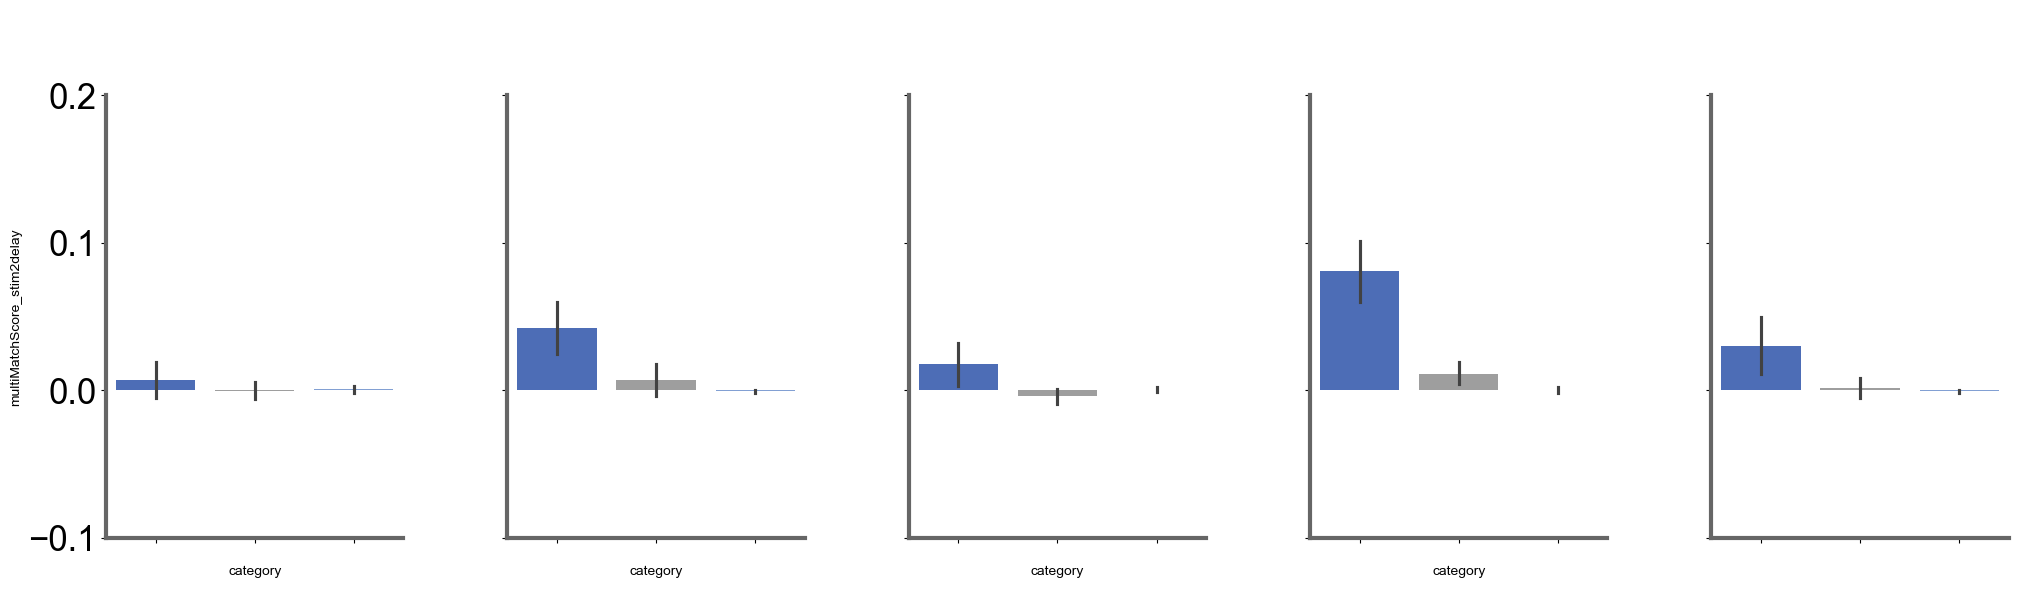

In [11]:
f = sns.catplot( y =f'multiMatchScore_{comparison}',x = 'category',hue = 'category',
                order =what2Draw,
                palette=['#9e9e9eff','#759ce0','#3b66c8',],
                col_order=dimensionOrder,row_order=['precue','retrocue'],col = 'dimension',aspect=0.75
                ,height=5.3,kind = 'bar',
            data = acrossSameDiff[acrossSameDiff.task == 'precue'])

labelOrder = ['shape', 'direction', 'length', 'position', 'duration','','','','','']

for n,ax in enumerate(f.axes.flat):
    ax.tick_params(labelsize=25)
    ax.set_title(labelOrder[n],color = 'white',fontsize = 30,)
    ax.set_xticks(ticks=[0, 1, 2], labels=['within', 'same image', 'diff image'],color = 'white',fontsize = 10)
    for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))

plt.xlabel('condition',fontsize = 15,color = 'white')
#
# plt.subplots_adjust(top=0.9)
plt.suptitle(f'subj average \n {comparison} comparison',fontsize = 20,y = 1.1,c = 'white')
plt.ylim(-0.1,0.2)
#
# plt.tight_layout()
plt.subplots_adjust(wspace=0.35)



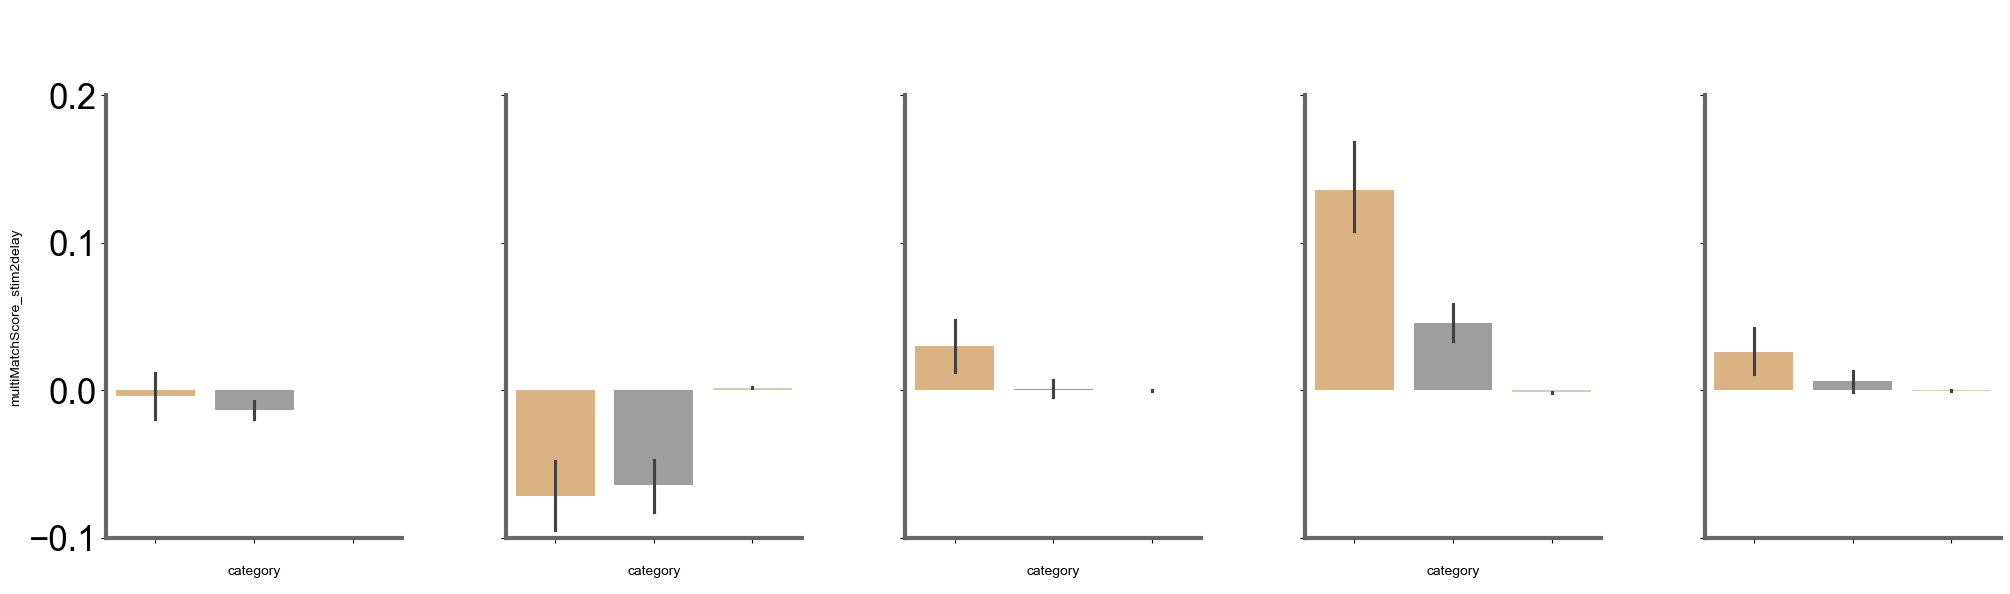

In [12]:


f = sns.catplot( y =f'multiMatchScore_{comparison}',x = 'category',hue = 'category',
                order =what2Draw,
                palette=['#9e9e9eff','#e2ccae','#eab375',],
                col_order=dimensionOrder,row_order=['precue','retrocue'],col = 'dimension',aspect=0.75
                ,height=5.3,kind = 'bar',
            data = acrossSameDiff[acrossSameDiff.task == 'retrocue'])

labelOrder = ['shape', 'direction', 'length', 'position', 'duration','','','','','']

for n,ax in enumerate(f.axes.flat):
    ax.tick_params(labelsize=25)
    ax.set_title(labelOrder[n],color = 'white',fontsize = 30)
    ax.set_xticks(ticks=[0, 1, 2],color = 'white', labels=['within', 'same image', 'diff image'],fontsize = 10)
    for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))

plt.xlabel('condition',color = 'white',fontsize = 15)
#
# plt.subplots_adjust(top=0.9)
plt.suptitle(f'subj average \n {comparison} comparison',color = 'white',fontsize = 20,y = 1.1)
plt.ylim(-0.1,0.2)
#
# plt.tight_layout()
plt.subplots_adjust(wspace=0.35)



In [13]:
for metric in dimensionOrder:
    print(metric)
    display(pg.rm_anova(subject='participant',within = 'category', dv = 'multiMatchScore_stim2delay',
                data = acrossSameDiff[(acrossSameDiff.task == 'precue')&(acrossSameDiff.dimension == metric)],
                effsize = 'np2'
                ).round(3)
                
                )

shape


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,0.939,0.395,0.023,0.685


direction


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,14.342,0.0,0.264,0.77


length


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,6.179,0.003,0.134,0.593


position


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,44.982,0.0,0.529,0.587


duration


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,8.421,0.0,0.174,0.613


In [14]:
for metric in dimensionOrder:
    print(metric)
    display(pg.rm_anova(subject='participant',within = 'category', dv = 'multiMatchScore_stim2delay',effsize = 'np2',
                data = acrossSameDiff[(acrossSameDiff.task == 'retrocue')&(acrossSameDiff.dimension == metric)]).round(3))

shape


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,2.324,0.104,0.055,0.616


direction


,Source,ddof1,ddof2,F,p-unc,p-GG-corr,np2,eps,sphericity,W-spher,p-spher
0,category,2,80,28.879,0.0,0.0,0.419,0.795,False,0.742,0.003


length


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,8.468,0.0,0.175,0.561


position


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,65.859,0.0,0.622,0.654


duration


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,category,2,80,6.983,0.002,0.149,0.635


In [15]:
jj = []

for metric in dimensionOrder:
    print(metric,)
    t,p = stats.ttest_rel(acrossSameDiff[(acrossSameDiff.category =='across trial') & (acrossSameDiff.task =='precue') &
                               (acrossSameDiff.dimension == metric) ].multiMatchScore_stim2delay,
                acrossSameDiff[(acrossSameDiff.category =='diff image') & (acrossSameDiff.task =='precue')&
                               (acrossSameDiff.dimension == metric) ].multiMatchScore_stim2delay,
                            nan_policy='omit')
    jj.append((t,p))
    print(' ',f't:{t:.3f},p:{p:.3f}')

shape
  t:-0.289,p:0.774
direction
  t:1.301,p:0.201
length
  t:-1.701,p:0.097
position
  t:2.972,p:0.005
duration
  t:0.563,p:0.576


In [16]:
jj = []

for metric in dimensionOrder:
    print(metric,)
    t,p = stats.ttest_rel(acrossSameDiff[(acrossSameDiff.category =='across trial') & (acrossSameDiff.task =='retrocue') &
                               (acrossSameDiff.dimension == metric) ].multiMatchScore_stim2delay,
                acrossSameDiff[(acrossSameDiff.category =='diff image') & (acrossSameDiff.task =='retrocue')&
                               (acrossSameDiff.dimension == metric) ].multiMatchScore_stim2delay,
                            nan_policy='omit')
    jj.append((t,p))
    print(' ',f't:{t:.3f},p:{p:.3f}')

shape
  t:-4.427,p:0.000
direction
  t:-7.540,p:0.000
length
  t:0.347,p:0.730
position
  t:7.215,p:0.000
duration
  t:1.728,p:0.092


# Supplementary Figure 2

In [17]:
meanDf = trl_withScore_formatted.groupby(['participant','category','task','trlType','dimension']).mean(numeric_only=True).reset_index()

acrossSameDiff = meanDf[meanDf.category.isin([
                    'within',
                    'across trial, visTarget',
                    'across trial, verTarget',
                    'diff image, visTarget',
                    'diff image, verTarget',
                    ])].reset_index(drop = True)

acrossSameDiff = acrossSameDiff.rename(columns = {'similarityScore_stim2delay':'multiMatchScore_stim2delay'})
# add in tags

tarType = []

for targetType,baseType in zip(acrossSameDiff.category,acrossSameDiff.trlType):
    if 'vis' in targetType:
        tarType.append('visual')
    elif 'ver' in targetType:
        tarType.append('verbal')
    else:
        tarType.append(baseType)

acrossSameDiff['targetType'] = tarType


cateType = []

for i in acrossSameDiff.category:
    if 'across trial' in i:
        cateType.append('across trial')
    elif 'diff' in i:
        cateType.append('diff image')
    else:
        cateType.append('within')
acrossSameDiff['category'] = cateType

In [18]:
for metric in dimensionOrder:

    print(f'Dimension: {metric}')
    #filter for congruent trials only
    result = pg.rm_anova(subject='participant', within=['category','trlType'], dv='multiMatchScore_stim2delay',
                         data=acrossSameDiff[(acrossSameDiff.task == 'precue') & 
                                             (acrossSameDiff.dimension == metric) &
                                             (acrossSameDiff.targetType == acrossSameDiff.trlType)])
    display(result[['Source', 'F', 'ddof1', 'ddof2', 'p-unc', 'ng2']].round(3))


Dimension: shape


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,0.537,2,80,0.586,0.001
1,trlType,0.429,1,40,0.516,0.008
2,category * trlType,0.188,2,80,0.829,0.000


Dimension: direction


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,10.191,2,80,0.000,0.063
1,trlType,0.669,1,40,0.418,0.007
2,category * trlType,1.178,2,80,0.313,0.005


Dimension: length


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,6.227,2,80,0.003,0.018
1,trlType,0.383,1,40,0.540,0.007
2,category * trlType,0.153,2,80,0.858,0.000


Dimension: position


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,44.228,2,80,0.000,0.200
1,trlType,4.533,1,40,0.039,0.060
2,category * trlType,0.808,2,80,0.449,0.002


Dimension: duration


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,7.749,2,80,0.001,0.038
1,trlType,6.176,1,40,0.017,0.070
2,category * trlType,0.543,2,80,0.583,0.002


In [19]:
for metric in dimensionOrder:

    print(f'Dimension: {metric}')
    #filter for congruent trials only
    result = pg.rm_anova(subject='participant', within=['category','trlType'], dv='multiMatchScore_stim2delay',
                         data=acrossSameDiff[(acrossSameDiff.task == 'retrocue') & 
                                             (acrossSameDiff.dimension == metric) &
                                             (acrossSameDiff.targetType == acrossSameDiff.trlType)])
    display(result[['Source', 'F', 'ddof1', 'ddof2', 'p-unc', 'ng2']].round(3))


Dimension: shape


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,3.382,2,80,0.039,0.009
1,trlType,3.584,1,40,0.066,0.064
2,category * trlType,0.528,2,80,0.592,0.001


Dimension: direction


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,25.977,2,80,0.000,0.143
1,trlType,5.106,1,40,0.029,0.034
2,category * trlType,3.023,2,80,0.054,0.014


Dimension: length


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,9.356,2,80,0.000,0.038
1,trlType,6.081,1,40,0.018,0.089
2,category * trlType,0.034,2,80,0.966,0.000


Dimension: position


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,63.732,2,80,0.000,0.313
1,trlType,0.005,1,40,0.943,0.000
2,category * trlType,0.713,2,80,0.493,0.001


Dimension: duration


,Source,F,ddof1,ddof2,p-unc,ng2
0,category,4.370,2,80,0.016,0.016
1,trlType,0.181,1,40,0.673,0.003
2,category * trlType,0.272,2,80,0.762,0.001


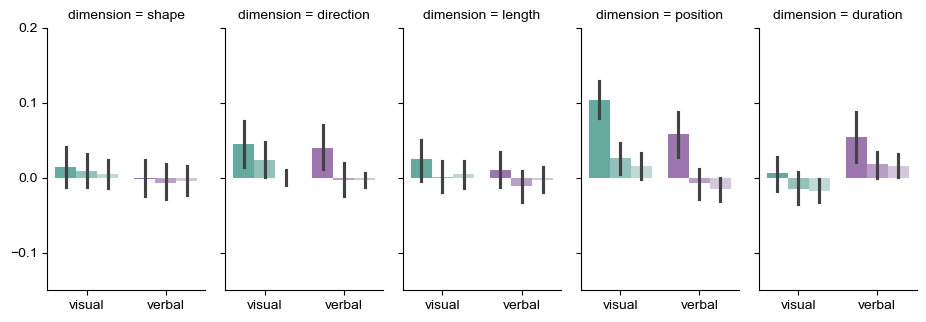

In [20]:

green_shades  = sns.light_palette('#59b6a6', n_colors=4)[1:][::-1]   # dark -> light green, 3 shades
purple_shades = sns.light_palette('#a06bb9', n_colors=4)[1:][::-1]    # dark -> light purple, 3 shades

hue_order = ['within', 'across trial', 'diff image']
plot_data = acrossSameDiff[(acrossSameDiff.task == 'precue') &
                            (acrossSameDiff.trlType == acrossSameDiff.targetType)]

g = sns.FacetGrid(plot_data, col='dimension', col_order=dimensionOrder,
                   height=3.5, aspect=0.55)

def plot_split_colors(data, **kwargs):
    ax = plt.gca()
    sns.barplot(data=data[data.trlType == 'visual'],
                x='trlType', y=f'multiMatchScore_{comparison}',
                hue='category', hue_order=hue_order, order=['visual', 'verbal'],
                palette=green_shades, dodge=True, ax=ax)
    sns.barplot(data=data[data.trlType == 'verbal'],
                x='trlType', y=f'multiMatchScore_{comparison}',
                hue='category', hue_order=hue_order, order=['visual', 'verbal'],
                palette=purple_shades, dodge=True, ax=ax)
    ax.get_legend().remove()  # each barplot call adds its own; drop both, add one shared legend after

g.map_dataframe(plot_split_colors)

# build one shared legend manually since per-facet legends were removed
g.figure.legend().remove()


for n,ax in enumerate(f.axes.flat):
    ax.tick_params(labelsize=50,)
    ax.set_title(labelOrder[n],fontsize = 30)
    ax.set_xticks(ticks=[0,1,2], labels=['within trial','same image','diff image'],
                  rotation = 30,fontsize = 20)
plt.gca().set_ylim(-0.15,0.2)
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))
g.set_axis_labels('', '')

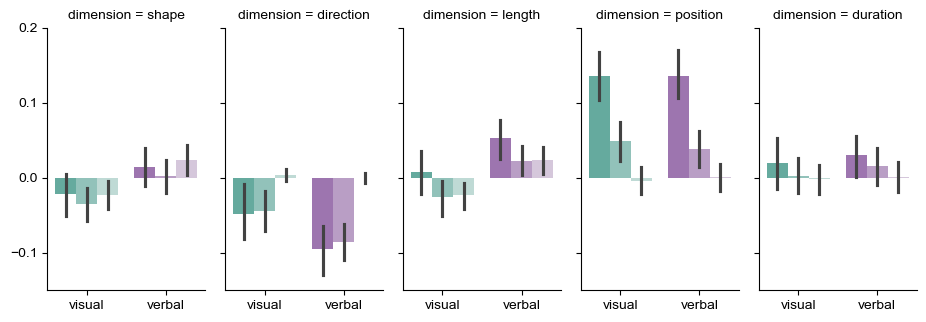

In [21]:

green_shades  = sns.light_palette('#59b6a6', n_colors=4)[1:][::-1]   # dark -> light green, 3 shades
purple_shades = sns.light_palette('#a06bb9', n_colors=4)[1:][::-1]    # dark -> light purple, 3 shades

hue_order = ['within', 'across trial', 'diff image']
plot_data = acrossSameDiff[(acrossSameDiff.task == 'retrocue') &
                            (acrossSameDiff.trlType == acrossSameDiff.targetType)]

g = sns.FacetGrid(plot_data, col='dimension', col_order=dimensionOrder,
                   height=3.5, aspect=0.55)

def plot_split_colors(data, **kwargs):
    ax = plt.gca()
    sns.barplot(data=data[data.trlType == 'visual'],
                x='trlType', y=f'multiMatchScore_{comparison}',
                hue='category', hue_order=hue_order, order=['visual', 'verbal'],
                palette=green_shades, dodge=True, ax=ax)
    sns.barplot(data=data[data.trlType == 'verbal'],
                x='trlType', y=f'multiMatchScore_{comparison}',
                hue='category', hue_order=hue_order, order=['visual', 'verbal'],
                palette=purple_shades, dodge=True, ax=ax)
    ax.get_legend().remove()  # each barplot call adds its own; drop both, add one shared legend after

g.map_dataframe(plot_split_colors)

# build one shared legend manually since per-facet legends were removed
g.figure.legend().remove()


labelOrder = ['shape', 'direction', 'length', 'position', 'duration','','','','','']

for n,ax in enumerate(f.axes.flat):
    ax.tick_params(labelsize=50,)
    ax.set_title(labelOrder[n],fontsize = 30)
    ax.set_xticks(ticks=[0,1,2], labels=['within trial','same image','diff image'],
                  rotation = 30,fontsize = 20)

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))
plt.gca().set_ylim(-0.15,0.2)
g.set_axis_labels('', '')


# Figure 3C

In [22]:
jj = []
for metric in dimensionOrder:
    print(metric,)
    q = stats.ttest_rel(acrossSameDiff[(acrossSameDiff.category =='within') & (acrossSameDiff.task =='precue') &
                               (acrossSameDiff.dimension == metric) & (acrossSameDiff.trlType == 'visual')].multiMatchScore_stim2delay,
                acrossSameDiff[(acrossSameDiff.category =='within') & (acrossSameDiff.task =='precue')&
                               (acrossSameDiff.dimension == metric) & (acrossSameDiff.trlType == 'verbal')].multiMatchScore_stim2delay,
                            nan_policy='omit')
    jj.append(q)
    print(' ',q)

withinPrecue = pd.DataFrame(jj)
withinPrecue['metric'] = ['shape','direction','length','position','duration']
withinPrecue

shape
  TtestResult(statistic=0.6578177988943092, pvalue=0.514423321780668, df=40)
direction
  TtestResult(statistic=0.21336230808875847, pvalue=0.8321281559500053, df=40)
length
  TtestResult(statistic=0.6378180517796196, pvalue=0.5272267137454734, df=40)
position
  TtestResult(statistic=2.2869116663199076, pvalue=0.027569445376791926, df=40)
duration
  TtestResult(statistic=-2.263562582883592, pvalue=0.029097056132096406, df=40)


,statistic,pvalue,metric
0,0.657818,0.514423,shape
1,0.213362,0.832128,direction
2,0.637818,0.527227,length
3,2.286912,0.027569,position
4,-2.263563,0.029097,duration


In [23]:
jj = []

for metric in dimensionOrder:
    print(metric,)
    q = stats.ttest_rel(acrossSameDiff[(acrossSameDiff.category =='within') & (acrossSameDiff.task =='retrocue') &
                               (acrossSameDiff.dimension == metric) & (acrossSameDiff.trlType == 'visual')].multiMatchScore_stim2delay,
                acrossSameDiff[(acrossSameDiff.category =='within') & (acrossSameDiff.task =='retrocue')&
                               (acrossSameDiff.dimension == metric) & (acrossSameDiff.trlType == 'verbal')].multiMatchScore_stim2delay,
                            nan_policy='omit')
    jj.append(q)
    print(' ',q)
    
withinRetrocue = pd.DataFrame(jj)
withinRetrocue['metric'] = ['shape','direction','length','position','duration']
withinRetrocue

shape
  TtestResult(statistic=-1.493000972194457, pvalue=0.14328336721240903, df=40)
direction
  TtestResult(statistic=1.9941350111365888, pvalue=0.05298504306367651, df=40)
length
  TtestResult(statistic=-2.066483543389244, pvalue=0.04529925882165636, df=40)
position
  TtestResult(statistic=-0.05881876175023299, pvalue=0.9533893380881631, df=40)
duration
  TtestResult(statistic=-0.38496080561515283, pvalue=0.7023058490685976, df=40)


,statistic,pvalue,metric
0,-1.493001,0.143283,shape
1,1.994135,0.052985,direction
2,-2.066484,0.045299,length
3,-0.058819,0.953389,position
4,-0.384961,0.702306,duration


(-0.15, 0.2)

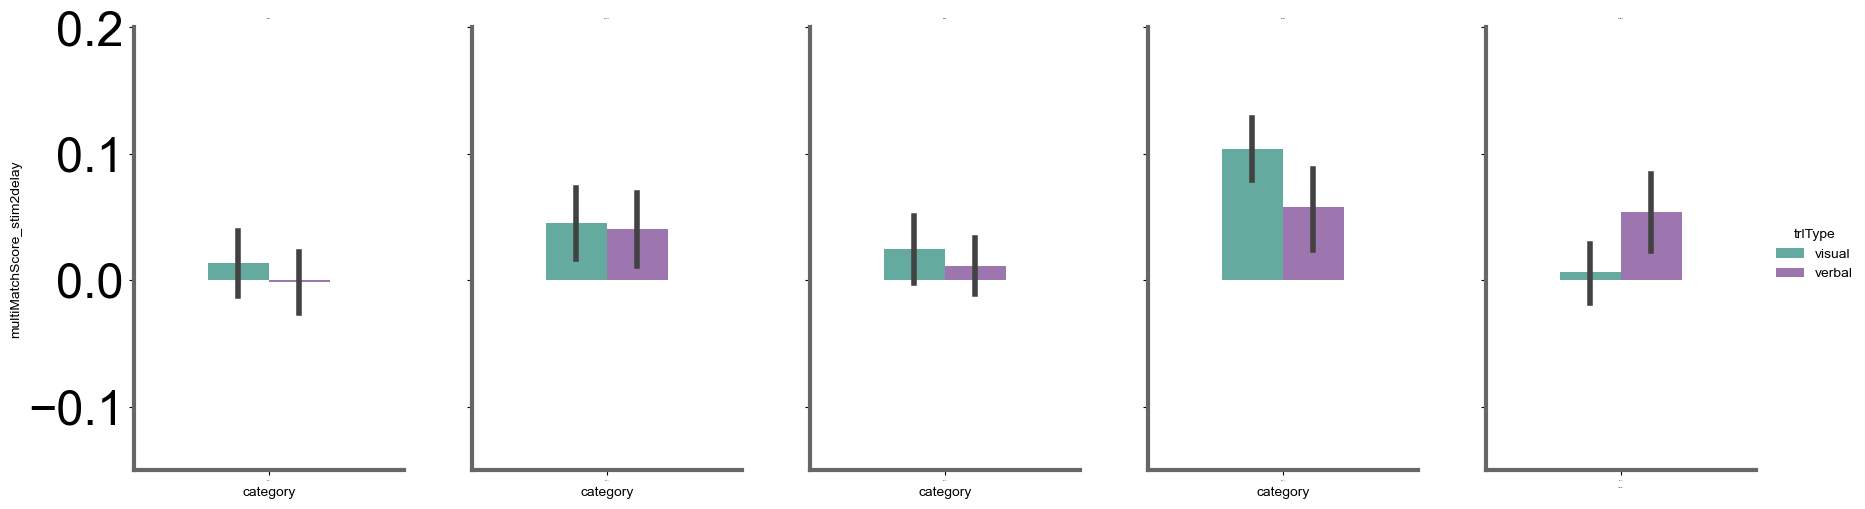

In [24]:
f = sns.catplot( y =f'multiMatchScore_{comparison}',x = 'category',hue = 'trlType',
                order =['within'],hue_order=['visual','verbal'],
                palette=['#59b6a6','#a06bb9',],width=0.45,errwidth = 4,
                col_order=dimensionOrder,
                col = 'dimension',aspect=0.65
                ,height=5.3,kind = 'bar',
            data = acrossSameDiff[acrossSameDiff.task == 'precue'])

labelOrder = ['shape', 'direction', 'length', 'position', 'duration','','','','','']

for n,ax in enumerate(f.axes.flat):
    ax.tick_params(labelsize=35)
    ax.set_title(labelOrder[n],fontsize = 0)
    ax.set_xticks(ticks=[0,], labels=['within',],fontsize = 0)
    for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))

plt.xlabel('condition',fontsize = 0)
#
plt.subplots_adjust(wspace=0.25)
#plt.suptitle(f'subj average \n {comparison} comparison',fontsize = 20,y = 1.1)
#plt.ylim(2.4,2.55)
plt.ylim(-0.15,0.2)

# plt.tight_layout()



(-0.15, 0.2)

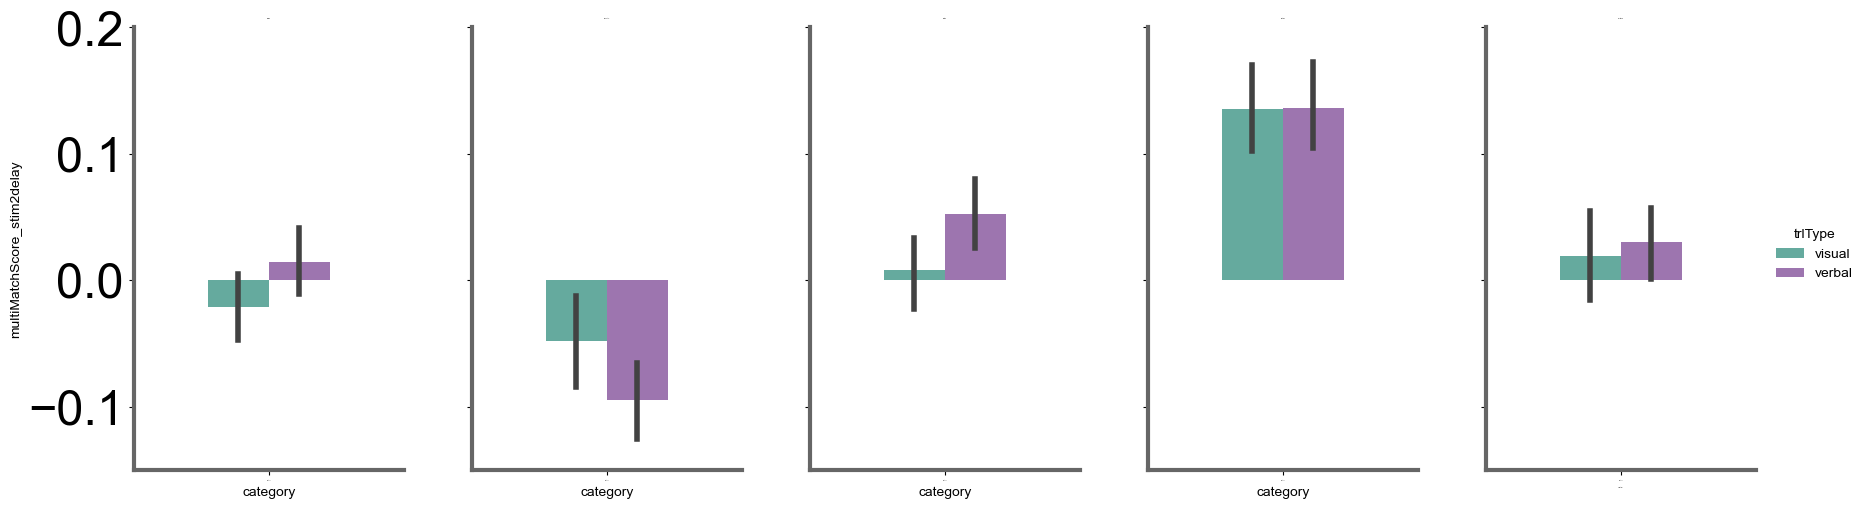

In [25]:

f = sns.catplot( y =f'multiMatchScore_{comparison}',x = 'category',hue = 'trlType',
                order =['within'],hue_order=['visual','verbal'],
                palette=['#59b6a6','#a06bb9',],width=0.45,errwidth = 4,
                col_order=dimensionOrder,
                col = 'dimension',aspect=0.65
                ,height=5.3,kind = 'bar',
            data = acrossSameDiff[acrossSameDiff.task == 'retrocue'])

labelOrder = ['shape', 'direction', 'length', 'position', 'duration','','','','','']

for n,ax in enumerate(f.axes.flat):
    ax.tick_params(labelsize=35)
    ax.set_title(labelOrder[n],fontsize = 0)
    ax.set_xticks(ticks=[0,], labels=['within',],fontsize = 0)
    for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_color('#666666')

plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(0.1))

plt.xlabel('condition',fontsize = 0)
#
plt.subplots_adjust(wspace=0.25)
#plt.suptitle(f'subj average \n {comparison} comparison',fontsize = 20,y = 1.1)
#plt.ylim(2.4,2.55)
plt.ylim(-0.15,0.2)

# plt.tight_layout()



# Response to reviewer 1 (demo of what multi match does)

In [26]:
egFixation = np.array([[820, 600, 0.2],
              [940, 500,  0.2],
              [1150, 550,  0.2]])
egFixation_delay = np.array([[880, 600, 0.2],
              [1060, 500,  0.2],
              [1160, 550,  0.2]])

egFixation_delay_revisit = np.array([[880, 600, 0.2],
              [1060, 500,  0.2],
              [1160, 550,  0.2],
              [1060, 500,  0.2],])

egFixation_reverse = egFixation_delay[::-1]
egFixation_reverse2 = np.array(
                       [[1160.0, 550.0, 0.2], 
                       [1060.0, 500.0, 0.2], 
                       [880.0, 600.0, 0.2],
                       [1060.0, 500.0, 0.2]]
)

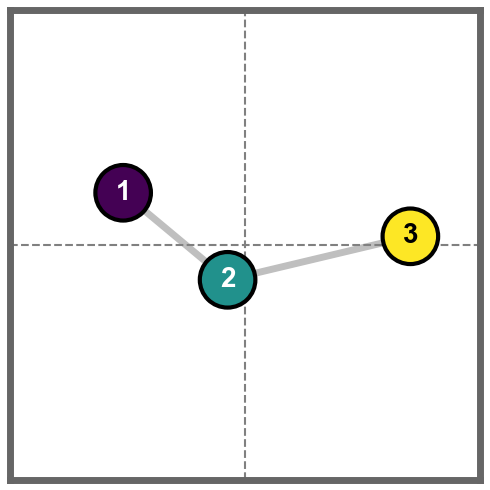

In [27]:
x, y, t = egFixation[:,0], egFixation[:,1], egFixation[:,2]

# Scale durations to bubble area
sizes = t * 8000  # adjust multiplier to taste

fig, ax = plt.subplots(figsize=(5,5))

# Draw scanpath lines
ax.plot(x, y, color='gray', linewidth=5, zorder=1, alpha=0.5)

# Draw fixation bubbles
sc = ax.scatter(x, y, s=sizes, c=np.linspace(0, 1, len(x)),
                cmap='viridis', alpha=1, edgecolors='black',
                linewidths=3, zorder=2)

cmap = plt.cm.viridis
norm_vals = np.linspace(0, 1, len(x))

for i, (xi, yi, nv) in enumerate(zip(x, y, norm_vals)):
    # viridis is dark below ~0.5, bright above — flip text color accordingly
    text_color = 'white' if nv < 0.6 else 'black'
    ax.text(xi, yi, str(i+1), ha='center', va='center',
            fontsize=20, fontweight='bold', color=text_color, zorder=3)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)

ax.invert_yaxis()  # screen coords: y increases downward

for spine in ax.spines.values():
    spine.set_linewidth(5) 
    spine.set_color('#666666')

plt.xlim(690, 1230)
plt.ylim(540-270,540+270)
plt.hlines(540,690, 1230,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.vlines(960,540-270,540+270,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.tight_layout()

plt.show()

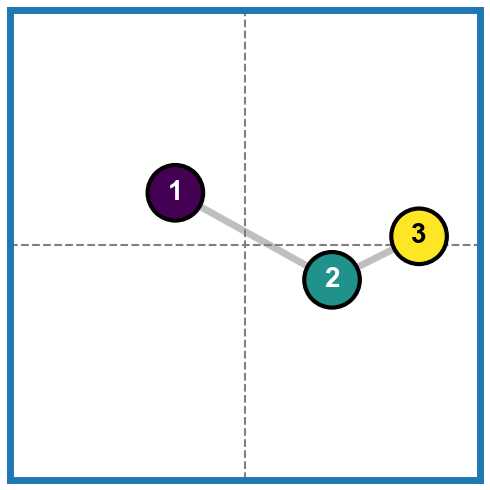

In [28]:
x, y, t = egFixation_delay[:,0], egFixation_delay[:,1], egFixation_delay[:,2]

# Scale durations to bubble area
sizes = t * 8000  # adjust multiplier to taste

fig, ax = plt.subplots(figsize=(5,5))

# Draw scanpath lines
ax.plot(x, y, color='gray', linewidth=5, zorder=1, alpha=0.5)

# Draw fixation bubbles
sc = ax.scatter(x, y, s=sizes, c=np.linspace(0, 1, len(x)),
                cmap='viridis', alpha=1, edgecolors='black',
                linewidths=3, zorder=2)

cmap = plt.cm.viridis
norm_vals = np.linspace(0, 1, len(x))

for i, (xi, yi, nv) in enumerate(zip(x, y, norm_vals)):
    # viridis is dark below ~0.5, bright above — flip text color accordingly
    text_color = 'white' if nv < 0.6 else 'black'
    ax.text(xi, yi, str(i+1), ha='center', va='center',
            fontsize=20, fontweight='bold', color=text_color, zorder=3)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)

ax.invert_yaxis()  # screen coords: y increases downward

for spine in ax.spines.values():
    spine.set_linewidth(5) 
    spine.set_color('#1f77b4')

plt.xlim(690, 1230)
plt.ylim(540-270,540+270)
plt.hlines(540,690, 1230,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.vlines(960,540-270,540+270,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.tight_layout()

plt.show()

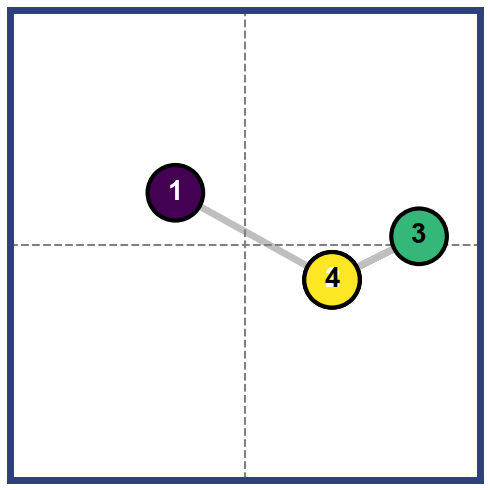

In [29]:
x, y, t = egFixation_delay_revisit[:,0], egFixation_delay_revisit[:,1], egFixation_delay_revisit[:,2]

# Scale durations to bubble area
sizes = t * 8000  # adjust multiplier to taste

fig, ax = plt.subplots(figsize=(5,5))

# Draw scanpath lines
ax.plot(x, y, color='gray', linewidth=5, zorder=1, alpha=0.5)

# Draw fixation bubbles
sc = ax.scatter(x, y, s=sizes, c=np.linspace(0, 1, len(x)),
                cmap='viridis', alpha=1, edgecolors='black',
                linewidths=3, zorder=2)

cmap = plt.cm.viridis
norm_vals = np.linspace(0, 1, len(x))

for i, (xi, yi, nv) in enumerate(zip(x, y, norm_vals)):
    # viridis is dark below ~0.5, bright above — flip text color accordingly
    text_color = 'white' if nv < 0.6 else 'black'
    ax.text(xi, yi, str(i+1), ha='center', va='center',
            fontsize=20, fontweight='bold', color=text_color, zorder=3)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)

ax.invert_yaxis()  # screen coords: y increases downward

for spine in ax.spines.values():
    spine.set_linewidth(5) 
    spine.set_color("#2e407c")

plt.xlim(690, 1230)
plt.ylim(540-270,540+270)
plt.hlines(540,690, 1230,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.vlines(960,540-270,540+270,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.tight_layout()

plt.show()

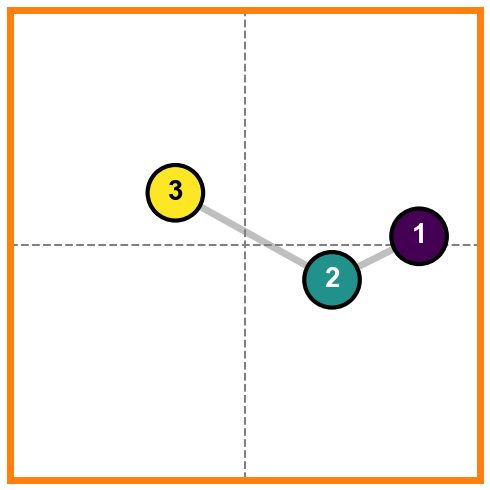

In [30]:
x, y, t = egFixation_reverse[:,0], egFixation_reverse[:,1], egFixation_reverse[:,2]

# Scale durations to bubble area
sizes = t * 8000  # adjust multiplier to taste

fig, ax = plt.subplots(figsize=(5,5))

# Draw scanpath lines
ax.plot(x, y, color='gray', linewidth=5, zorder=1, alpha=0.5)

# Draw fixation bubbles
sc = ax.scatter(x, y, s=sizes, c=np.linspace(0, 1, len(x)),
                cmap='viridis', alpha=1, edgecolors='black',
                linewidths=3, zorder=2)

cmap = plt.cm.viridis
norm_vals = np.linspace(0, 1, len(x))

for i, (xi, yi, nv) in enumerate(zip(x, y, norm_vals)):
    # viridis is dark below ~0.5, bright above — flip text color accordingly
    text_color = 'white' if nv < 0.6 else 'black'
    ax.text(xi, yi, str(i+1), ha='center', va='center',
            fontsize=20, fontweight='bold', color=text_color, zorder=3)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)

ax.invert_yaxis()  # screen coords: y increases downward

for spine in ax.spines.values():
    spine.set_linewidth(5) 
    spine.set_color('#ff7f0e')

plt.xlim(690, 1230)
plt.ylim(540-270,540+270)
plt.hlines(540,690, 1230,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.vlines(960,540-270,540+270,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.tight_layout()

plt.show()

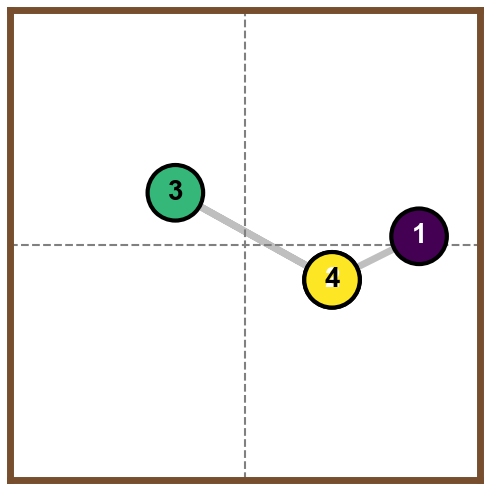

In [31]:
x, y, t = egFixation_reverse2[:,0], egFixation_reverse2[:,1], egFixation_reverse2[:,2]

# Scale durations to bubble area
sizes = t * 8000  # adjust multiplier to taste

fig, ax = plt.subplots(figsize=(5,5))

# Draw scanpath lines
ax.plot(x, y, color='gray', linewidth=5, zorder=1, alpha=0.5)

# Draw fixation bubbles
sc = ax.scatter(x, y, s=sizes, c=np.linspace(0, 1, len(x)),
                cmap='viridis', alpha=1, edgecolors='black',
                linewidths=3, zorder=2)

cmap = plt.cm.viridis
norm_vals = np.linspace(0, 1, len(x))

for i, (xi, yi, nv) in enumerate(zip(x, y, norm_vals)):
    # viridis is dark below ~0.5, bright above — flip text color accordingly
    text_color = 'white' if nv < 0.6 else 'black'
    ax.text(xi, yi, str(i+1), ha='center', va='center',
            fontsize=20, fontweight='bold', color=text_color, zorder=3)

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)

ax.invert_yaxis()  # screen coords: y increases downward

for spine in ax.spines.values():
    spine.set_linewidth(5) 
    spine.set_color("#774f2f")

plt.xlim(690, 1230)
plt.ylim(540-270,540+270)
plt.hlines(540,690, 1230,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.vlines(960,540-270,540+270,linestyles = 'dashed',color = 'grey',zorder = 0)
plt.tight_layout()

plt.show()

In [32]:
def to_multimatch_fixations(arr):
    """Convert (x, y, duration) ndarray to multimatch recarray format."""
    dt = np.dtype([('start_x', '<f8'), ('start_y', '<f8'), ('duration', '<f8')])
    rec = np.zeros(len(arr), dtype=dt)
    rec['start_x']  = arr[:, 0]
    rec['start_y']  = arr[:, 1]
    rec['duration'] = arr[:, 2]
    return rec

fix1 = to_multimatch_fixations(egFixation)
fix2 = to_multimatch_fixations(egFixation_delay)
fix2_revisit = to_multimatch_fixations(egFixation_delay_revisit)

fix2_reverse = to_multimatch_fixations(egFixation_reverse)
fix2_reverse2 = to_multimatch_fixations(egFixation_reverse2)


result = m.docomparison(fix1, fix2, screensize=[1920, 1080])
result_revisit = m.docomparison(fix1, fix2_revisit, screensize=[1920, 1080])

result2 = m.docomparison(fix1, fix2_reverse, screensize=[1920, 1080])
result3 = m.docomparison(fix1, fix2_reverse2, screensize=[1920, 1080])

In [33]:
out = np.hstack(
    [
    np.hstack([result,result_revisit,result2,result3])[:,None].astype(float), 
    np.array(
        ['shape','direction','length', 'position','duration']*4
        )[:,None],
    np.array(
        ['encoding-delay']*5 + ['encoding-revisit']*5 + \
        ['encoding-reverse_delay']*5+['encoding-reverse_delay_revisit']*5
        )[:,None]
    ]
)

In [34]:
out_df = pd.DataFrame(out, columns = ['value','metric','comparison'])
out_df['value'] = out_df.value.astype(float)

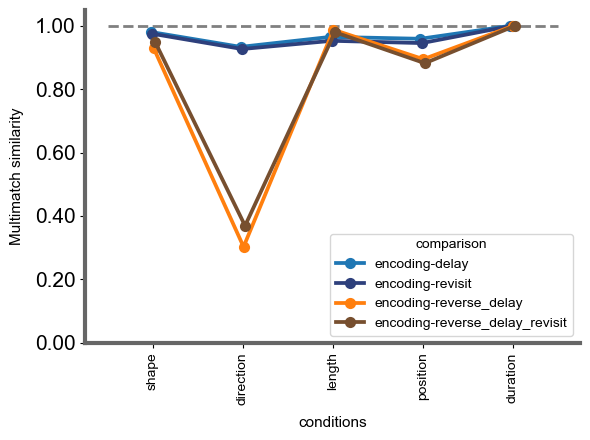

In [35]:
metric_order = ['shape', 'direction', 'length', 'position', 'duration']

fig, ax = plt.subplots(figsize=(6, 4.5))

sns.pointplot(
    data=out_df,
    hue='comparison', y='value',
    palette=['#1f77b4', '#2e407c', '#ff7f0e', '#774f2f'],
    x='metric', order=metric_order,
    dodge=0.05,
    err_kws={'linewidth': 1.2},
    markersize=6,
    ax=ax,
)

ax.set_xlabel('conditions', fontsize=11, labelpad=8)
ax.set_ylabel('Multimatch similarity', fontsize=11, labelpad=8)
ax.tick_params(axis='both', labelsize=10)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_linewidth(3)
ax.spines[['bottom', 'left']].set_color('#666666')

plt.hlines(y=1, xmin=-0.5, xmax=4.5, 
           linewidth=2,
           linestyles='dashed', color='grey', zorder=0)

plt.tick_params(labelsize=15)
plt.tick_params(axis = 'x',labelsize=10,rotation = 90)

plt.ylim(0,1.05)
plt.tight_layout()
plt.show()